In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rabieelkharoua/cancer-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 47.3k/47.3k [00:00<00:00, 38.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rabieelkharoua/cancer-prediction-dataset/versions/2


In [ ]:
# Load the dataset (Upload 'diabetes.csv' file to Colab)
from google.colab import files
uploaded = files.upload()

# Assuming 'diabetes.csv' is inside 'archive (1).zip'
import zipfile

# Import the pandas library
import pandas as pd

# Extract 'The_Cancer_data_1500_V2.csv' from the uploaded zip file
# The filename was likely incorrect. Assuming your file is a csv file,
# and it is named 'The_Cancer_data_1500_V2.csv' within the archive.
# Also, since you uploaded archive (2) (1).zip,
# that is probably the file name you should be using here
with zipfile.ZipFile('archive (2) (1).zip', 'r') as zip_ref:
    zip_ref.extract('The_Cancer_data_1500_V2.csv')

# Read the CSV file, now that it has been extracted
data = pd.read_csv('The_Cancer_data_1500_V2.csv') # Use pd.read_csv
data.head()

Saving archive (2).zip to archive (2) (1).zip


,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


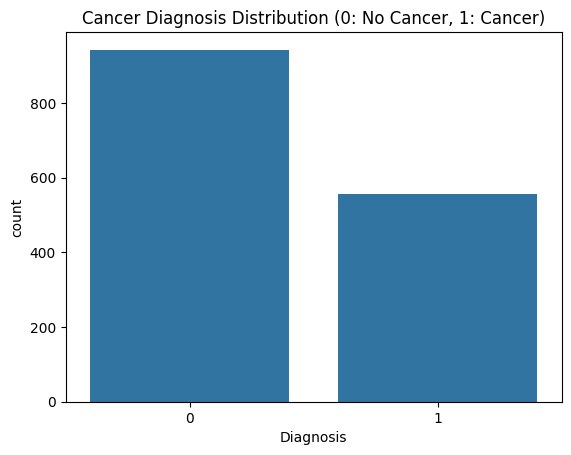

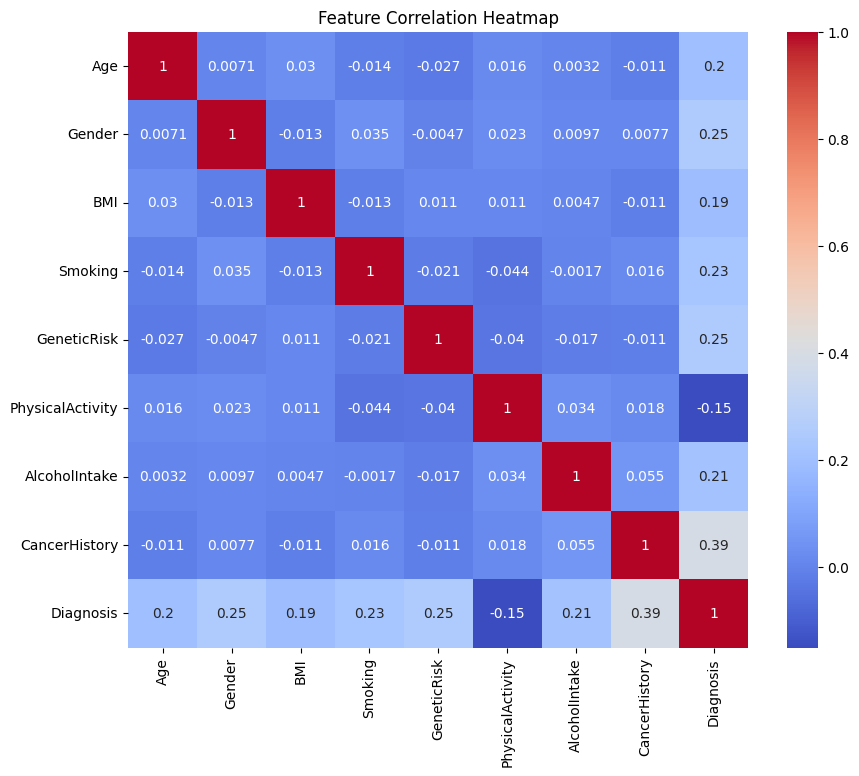

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize the target variable
# Use 'data' instead of 'df' as 'data' holds the dataframe
sns.countplot(data=data, x="Diagnosis")
plt.title("Cancer Diagnosis Distribution (0: No Cancer, 1: Cancer)")
plt.show()

# Correlation heatmap
# You'll need to calculate the correlation on your data
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# Define features (X) and target (y)
X = data.drop("Diagnosis", axis=1)  # Drop the target column
y = data["Diagnosis"]  # Target variable


In [ ]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(



Confusion Matrix:
[[136 147]
 [  7 160]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.48      0.64       283
           1       0.52      0.96      0.68       167

    accuracy                           0.66       450
   macro avg       0.74      0.72      0.66       450
weighted avg       0.79      0.66      0.65       450


Accuracy: 0.66
ROC-AUC Score: 0.86


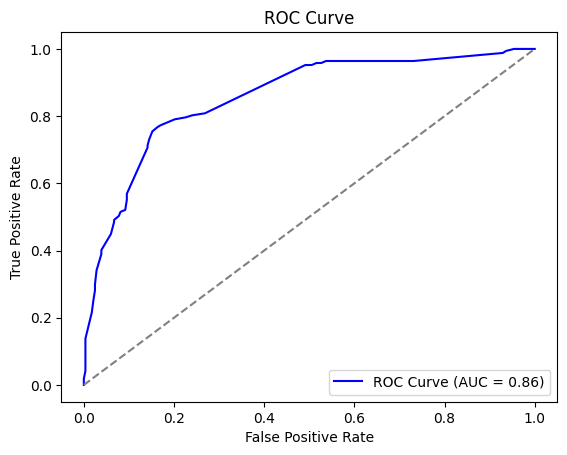

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Accuracy and ROC-AUC score
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nAccuracy: {accuracy:.2f}")
print(f"ROC-AUC Score: {roc_auc:.2f}")

# Plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, color="blue", label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


In [ ]:
import joblib

# Save the model as a .pkl file
joblib.dump(rf_model, "cancer_prediction_model.pkl")
print("Model saved as 'cancer_prediction_model.pkl'")


Model saved as 'cancer_prediction_model.pkl'


In [ ]:
# Import necessary libraries
import numpy as np

# Example patient data (Replace this with actual input values)
# [Age, Gender, BMI, Smoking, GeneticRisk, PhysicalActivity, AlcoholIntake, CancerHistory]
patient_data = [25, 0, 22.0, 0, 0, 6.0, 0.0, 0]

# Reshape the data for prediction (1 sample with 8 features)
patient_data_array = np.array(patient_data).reshape(1, -1)

# Make a prediction
# Changed 'model' to 'rf_model' to use the trained Random Forest model
prediction = rf_model.predict(patient_data_array)
prediction_proba = rf_model.predict_proba(patient_data_array)

# Output the results
if prediction[0] == 1:
    print("Prediction: The patient is likely to have cancer.")
else:
    print("Prediction: The patient is unlikely to have cancer.")

# Print probability
print(f"Probability of having cancer: {prediction_proba[0][1] * 100:.2f}%")
print(f"Probability of not having cancer: {prediction_proba[0][0] * 100:.2f}%")

Prediction: The patient is unlikely to have cancer.
Probability of having cancer: 21.00%
Probability of not having cancer: 79.00%
